LAB 7


1. Thresholding để phân đoạn ảnh

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

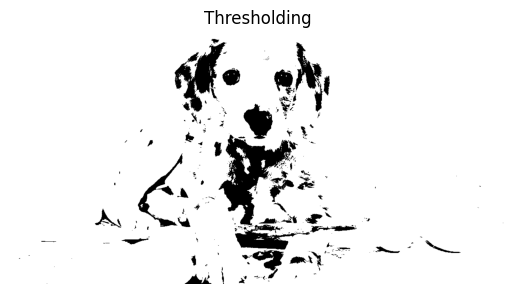

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as Quan

img = cv2.imread('dog.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, thresh = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

Quan.imshow(thresh, cmap='gray')
Quan.title("Thresholding")
Quan.axis('off')

2. Otsu algorithm để phân đoạn ảnh vân tay 

(np.float64(-0.5), np.float64(899.5), np.float64(595.5), np.float64(-0.5))

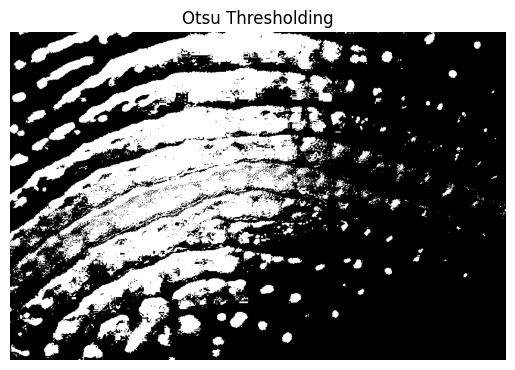

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as Quan

img = cv2.imread('vantay.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, otsu = cv2.threshold(gray,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

Quan.imshow(otsu, cmap='gray')
Quan.title("Otsu Thresholding")
Quan.axis('off')

3. Clustering techniques trong phân đoạn ảnh, K-mean clustering

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

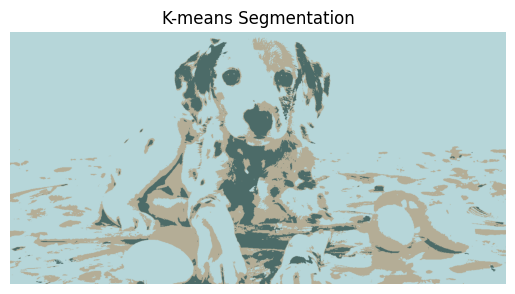

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as Quan

img = cv2.imread('dog.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

Z = img.reshape((-1,3))
Z = np.float32(Z)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,10,1.0)

K = 3
ret,label,center = cv2.kmeans(Z,K,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)

center = np.uint8(center)
res = center[label.flatten()]
result = res.reshape((img.shape))

Quan.imshow(result)
Quan.title("K-means Segmentation")
Quan.axis('off')

4. Sử dụng thuật toán Region growing

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

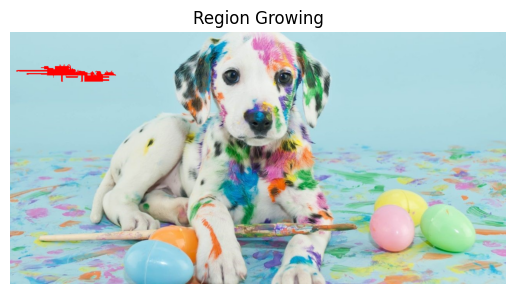

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as Quan

img = cv2.imread('dog.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]
mask = np.zeros((h+2, w+2), np.uint8)

seed = (100,100)

cv2.floodFill(img, mask, seed, (255,0,0))

Quan.imshow(img)
Quan.title("Region Growing")
Quan.axis('off')

5. Sử dụng thuật toán Split and merge để phân đoạn ảnh

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

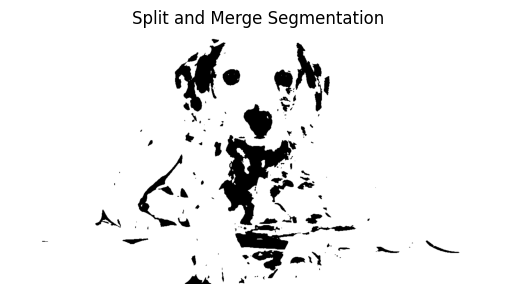

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as Quan

img = cv2.imread('dog.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray,(5,5),0)
ret,thresh = cv2.threshold(blur,128,255,cv2.THRESH_BINARY)

Quan.imshow(thresh,cmap='gray')
Quan.title("Split and Merge Segmentation")
Quan.axis('off')

6. Phân đoạn ảnh với Edge-based sigmentation

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

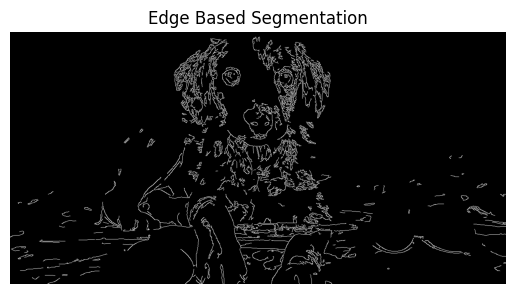

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as Quan

img = cv2.imread('dog.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray,100,200)

Quan.imshow(edges,cmap='gray')
Quan.title("Edge Based Segmentation")
Quan.axis('off')

LAB 8

In [ ]:
# Cài đặt thư viện 
!pip install imageai torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cpu

import os
from imageai.Detection import VideoObjectDetection

execution_path = os.getcwd()

# Khởi tạo detector
detector = VideoObjectDetection()
detector.setModelTypeAsRetinaNet()

# Đường dẫn đến model
model_path = os.path.join(execution_path, "retinanet_resnet50_fpn_coco-eeacb38b.pth")
detector.setModelPath(model_path)

# Load model 
detector.loadModel()

# Đường dẫn input và output
input_video = os.path.join(execution_path, "video_predetect.mp4")
output_video = os.path.join(execution_path, "video_detected")   # không cần .mp4, ImageAI sẽ tự thêm

# Thực hiện nhận dạng đối tượng
video_path = detector.detectObjectsFromVideo(
    input_file_path=input_video,
    output_file_path=output_video,
    frames_per_second=5,           # giảm để chạy nhanh hơn
    minimum_percentage_probability=50,   # ngưỡng tin cậy (có thể chỉnh 30-70)
    log_progress=True,
    return_detected_frame=False
)

print("Video đã xử lý xong. Đường dẫn output:", video_path)